In [1]:
#masukan data set yang kita bbutuh kan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
data_model = pd.read_csv('data_model_classificaton_banery.csv')
data_model.head(10) #MELIAHT 10 DATA TERATAS

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,100006,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,100007,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,100008,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,100009,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,100010,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [2]:
#data clanning
data_model.info() #melihat informasi tentang data set kita
data_model.describe() #melihat statistik data seprti mean, median, juumlah data, data unique, dll

#non-null dalam data_model adalah 1000, artinya tidak ada data yang kosong atau null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [3]:
data_model.isnull().sum() #melihat missing value pada data set kita


student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

In [4]:
data_model.duplicated().sum() #melihat data duplikat

0

In [5]:
data_model.isna().sum() #melihat data yang kosong

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

In [6]:
data_finalmodel = data_model.drop(columns=['student_id'], axis=1) #menghapus kolom student_id karena tidak berpengaruh pada model kita
data_finalmodel.head(10) #melihat 10 data teratas setelah menghapus kolom student_id

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [7]:
data_finalmodel.info() #melihat informasi tentang data set kita setelah menghapus kolom student_id

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   course                   150000 non-null  object 
 3   year                     150000 non-null  object 
 4   daily_study_hours        150000 non-null  float64
 5   daily_sleep_hours        150000 non-null  float64
 6   screen_time_hours        150000 non-null  float64
 7   stress_level             150000 non-null  object 
 8   anxiety_score            150000 non-null  int64  
 9   depression_score         150000 non-null  int64  
 10  academic_pressure_score  150000 non-null  int64  
 11  financial_stress_score   150000 non-null  int64  
 12  social_support_score     150000 non-null  int64  
 13  physical_activity_hours  150000 non-null  float64
 14  slee

In [8]:
data_finalmodel.tail(10) #melihat 10 data terakhir pada data set kita

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
149990,18,Female,BTech,1st,6.3,7.7,1.6,High,9,6,4,5,2,1.5,Average,89.8,5.48,Good,1
149991,17,Female,MCA,4th,7.0,6.7,10.2,Medium,10,4,1,4,8,0.3,Good,86.1,4.67,Average,1
149992,21,Male,BTech,4th,5.4,8.5,9.7,Low,7,5,7,1,7,1.6,Good,52.3,6.35,Good,1
149993,17,Female,BCA,4th,8.7,7.3,3.5,Medium,9,1,7,9,7,1.8,Poor,99.8,4.31,Good,1
149994,20,Male,MCA,4th,6.3,5.4,9.6,Medium,9,5,10,8,1,0.6,Good,77.2,9.31,Good,0
149995,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,0
149996,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,1
149997,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,1
149998,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,1
149999,20,Male,MCA,3rd,3.7,6.6,2.6,Medium,5,1,5,7,6,1.8,Good,89.8,7.00,Poor,1


In [9]:
data_finalmodel.describe() #melihat statistika dalam data set kita

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [10]:
data_finalmodel.isna().sum() #melihat data yang kosong pada data set kita


age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

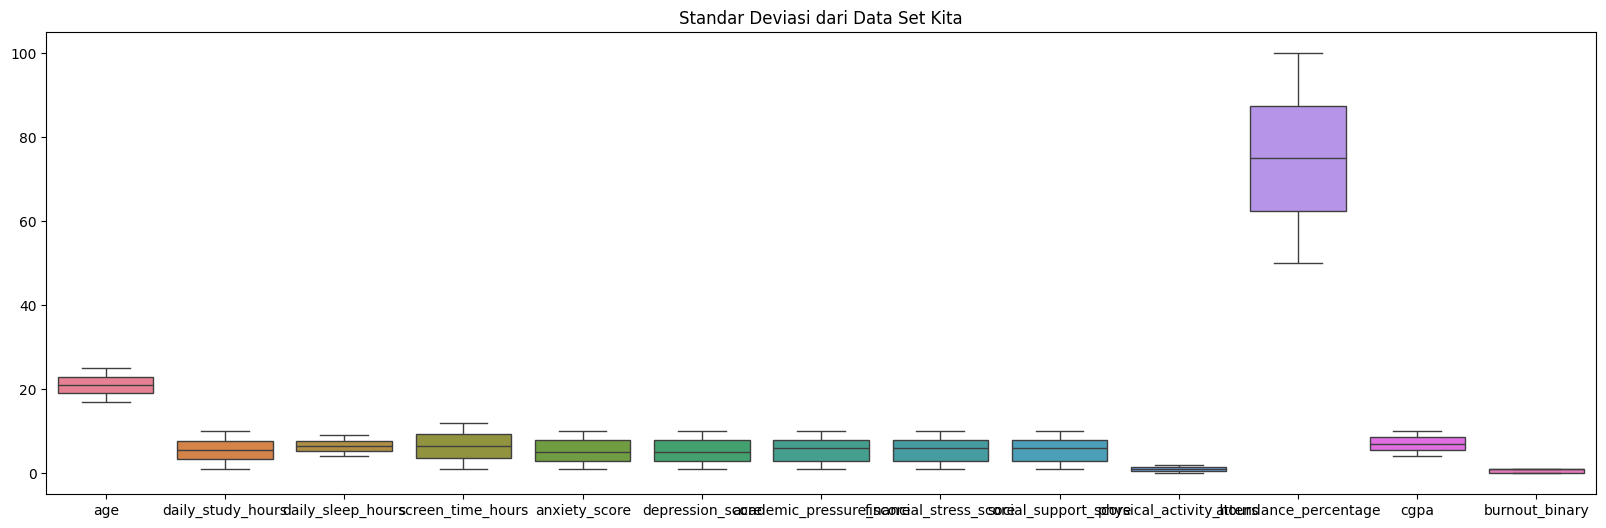

In [11]:
plt.figure(figsize=(20,6))
plt.title('Standar Deviasi dari Data Set Kita')
sns.boxplot(data=data_finalmodel)
plt.show() #melihat boxplot dari data set kita

In [12]:
#dstribusi frekuensi dari data set kita
data_object = data_finalmodel.select_dtypes(include='object') #melihat data yang bertipe object pada data set kita

In [13]:
for i in data_object.columns:
   print(f'====== distribusi frekuensi dari vareabel {i} ======')
   print(data_object[i].value_counts())
   
   

====== distribusi frekuensi dari vareabel gender ======
gender
Other     50048
Female    49988
Male      49964
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel course ======
course
MBA      25231
BBA      25103
BCA      24973
MCA      24950
BSc      24894
BTech    24849
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel year ======
year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel stress_level ======
stress_level
High      50295
Medium    50090
Low       49615
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel sleep_quality ======
sleep_quality
Good       50143
Average    49976
Poor       49881
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel internet_quality ======
internet_quality
Average    50138
Poor       49989
Good       49873
Name: count, dtype: int64


In [32]:
data_numerik = data_finalmodel.select_dtypes(include=['float64', 'int64']) #melihat data yang bertipe numerik pada data set kita
print(data_numerik) #melihat 10 data teratas pada data numerik


        age  daily_study_hours  daily_sleep_hours  screen_time_hours  \
0        23                4.3                6.8                6.1   
1        20                1.4                4.7                3.0   
2        24                3.7                4.8                1.5   
3        21                1.6                6.7                7.0   
4        23                2.0                6.7                5.4   
...     ...                ...                ...                ...   
149995   24                1.6                8.2               11.3   
149996   25                9.9                4.8                1.6   
149997   22                1.4                4.4                4.6   
149998   19                1.5                4.3                1.1   
149999   20                3.7                6.6                2.6   

        anxiety_score  depression_score  academic_pressure_score  \
0                  10                 3                        4   

In [37]:
for i in data_numerik.columns:
    data_numerik[i].unique() #melihat data unik pada data numerik
    print(f"Data unik pada variabel {i}: {data_numerik[i].unique()}")

Data unik pada variabel age: [23 20 24 21 19 22 18 17 25]
Data unik pada variabel daily_study_hours: [ 4.3  1.4  3.7  1.6  2.   8.2  3.   4.6  8.1  9.7  2.2  8.9  3.8  8.6
  5.3  2.1  6.3  8.8  5.5  6.5  9.2  7.4  4.4  6.   4.   1.1  9.9  1.8
  3.6  5.7  9.4  5.   5.4  9.6  9.1  6.7  4.8  8.4  9.8  4.7  5.2  3.1
  8.3  6.8  6.9  6.2  4.2  7.   5.6  2.5  2.7  5.8  2.6  3.9  7.5  3.4
  4.5  5.1  7.2  2.3  9.5 10.   7.6  6.6  1.3  7.9  8.   7.1  2.9  6.1
  6.4  3.5  1.5  4.9  7.8  2.8  1.2  8.7  1.7  1.9  7.7  3.2  8.5  9.
  2.4  9.3  4.1  1.   5.9  3.3  7.3]
Data unik pada variabel daily_sleep_hours: [6.8 4.7 4.8 6.7 8.  6.3 5.4 7.  6.  7.2 5.  7.9 8.4 5.3 5.1 6.9 8.6 4.
 6.4 8.2 8.9 8.7 4.5 7.5 4.3 6.6 8.3 7.4 4.9 4.1 4.4 6.5 5.9 7.8 5.6 8.5
 6.1 7.6 5.8 5.5 6.2 7.7 8.8 5.7 4.2 7.3 5.2 4.6 8.1 7.1 9. ]
Data unik pada variabel screen_time_hours: [ 6.1  3.   1.5  7.   5.4  4.1  7.8  7.6  1.3 11.5  6.4  3.5  1.6  1.1
 10.5 11.1  3.2  5.7  9.3 11.9 10.4  8.9 11.7  2.7 11.2 10.7  5.6  9.6
 1

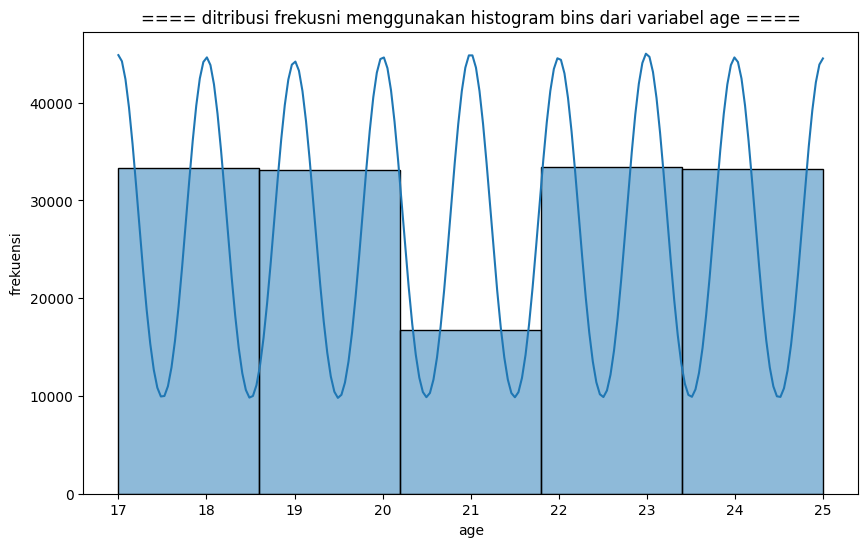

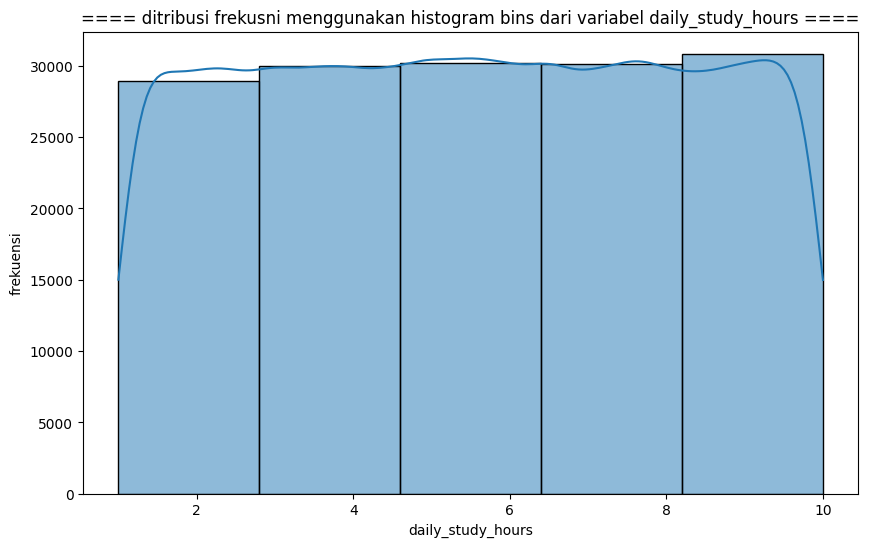

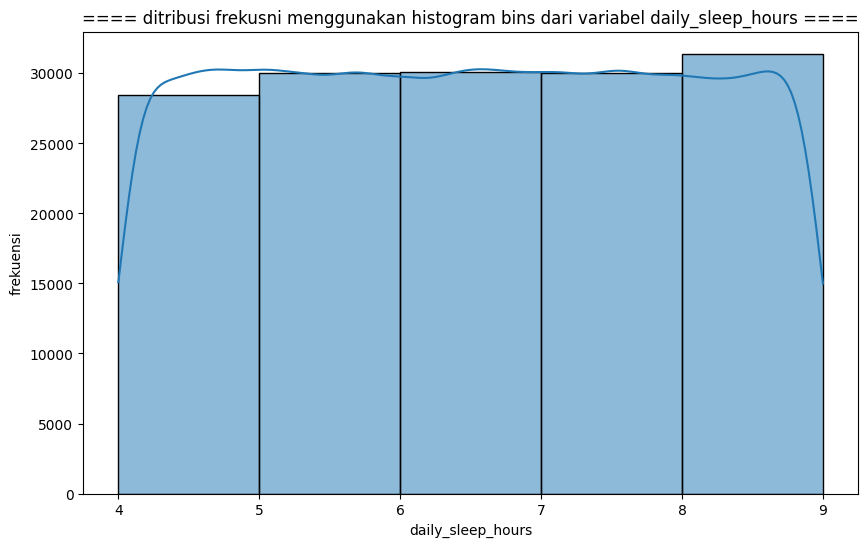

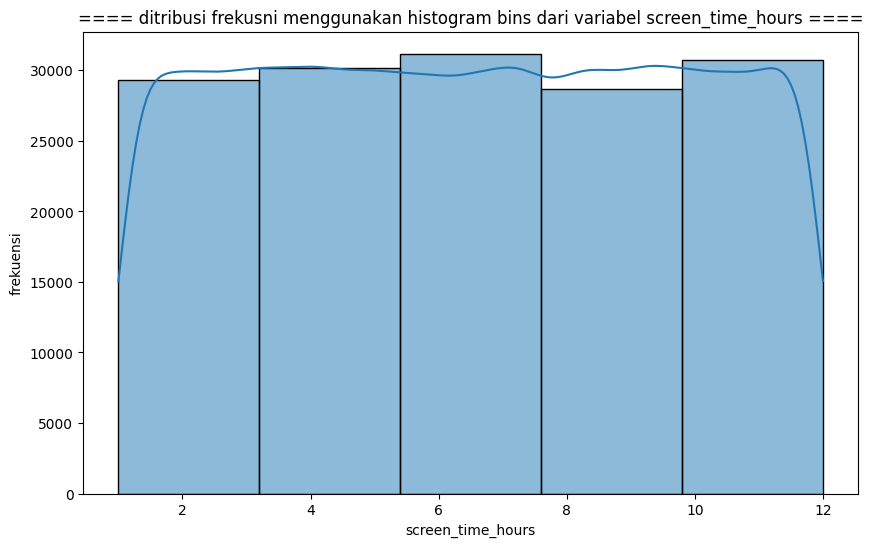

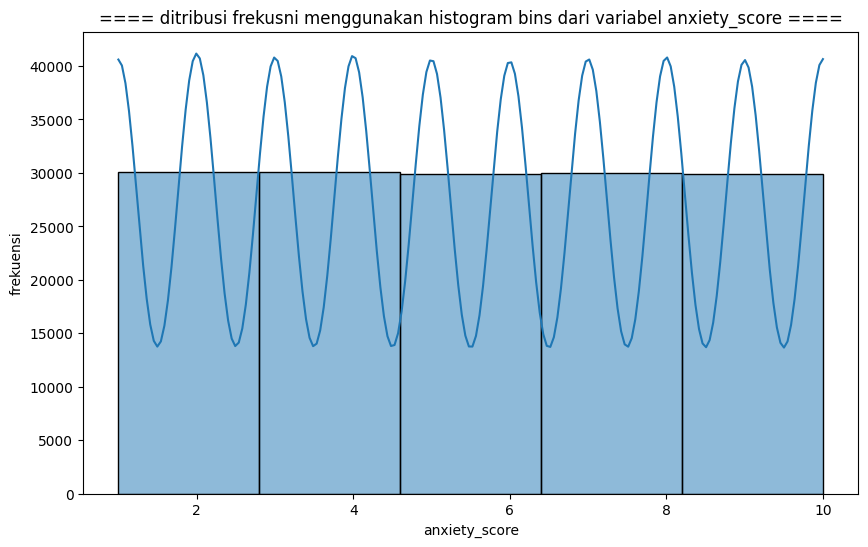

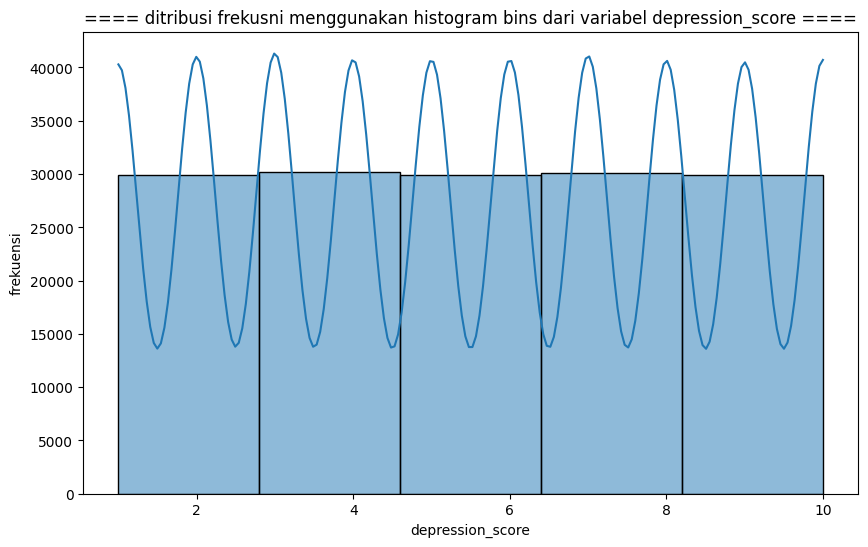

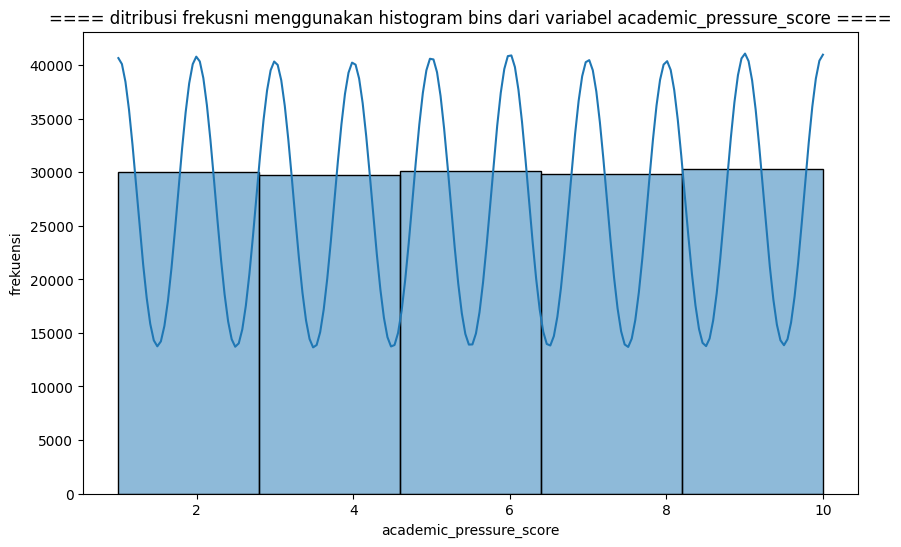

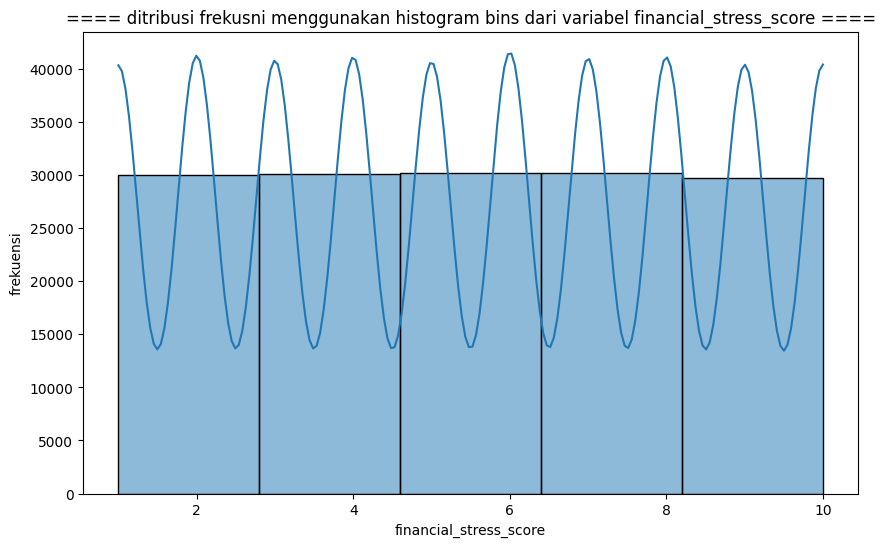

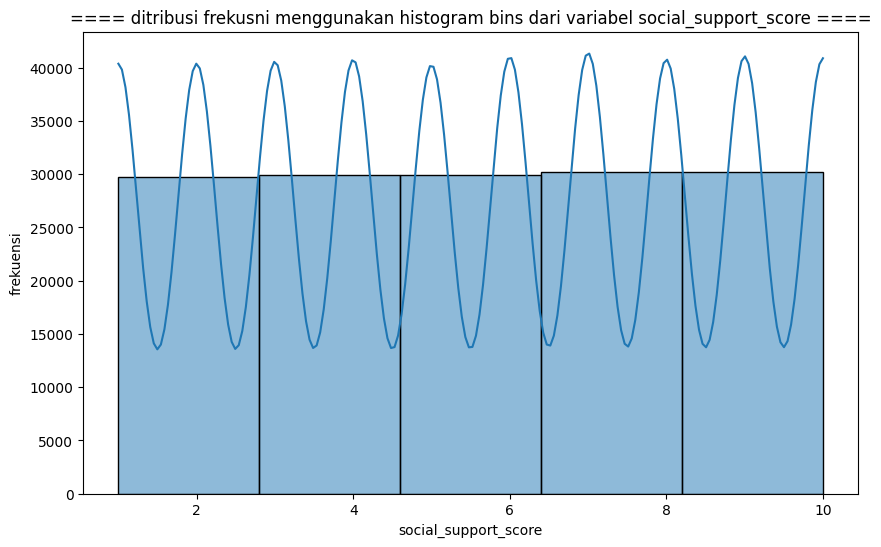

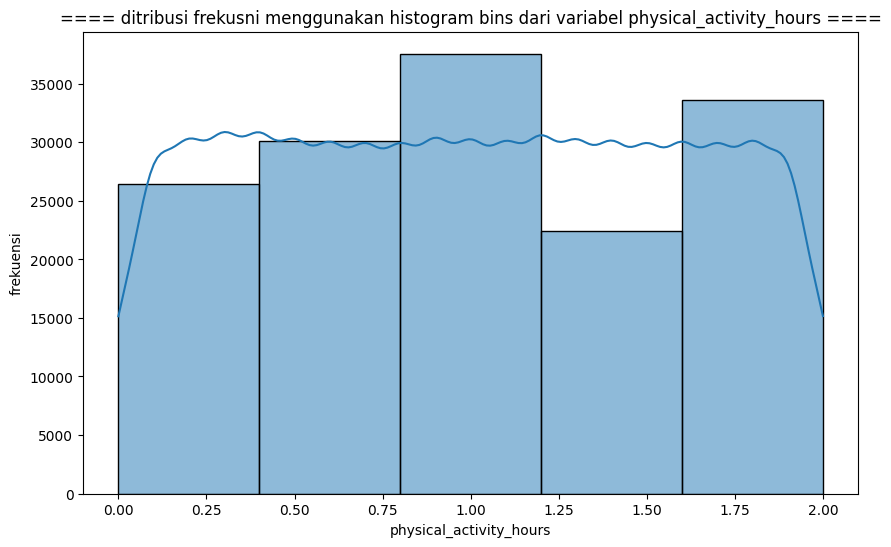

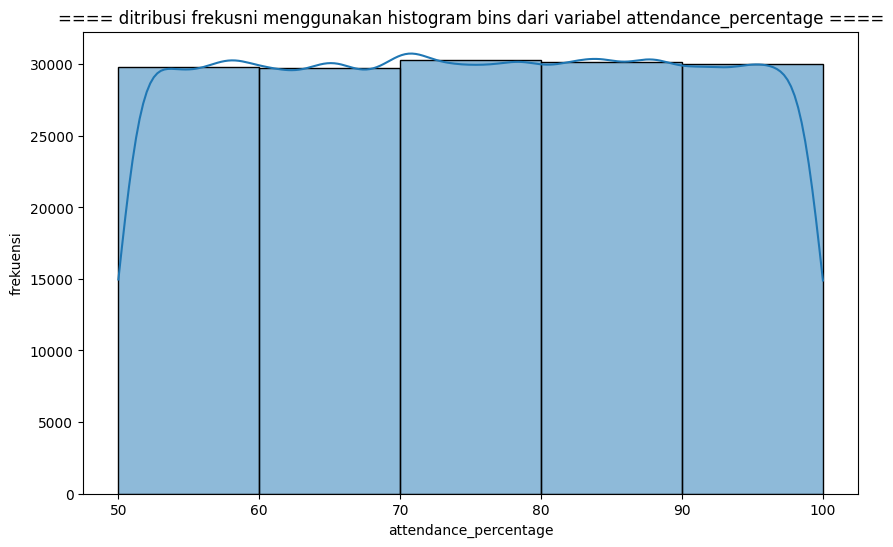

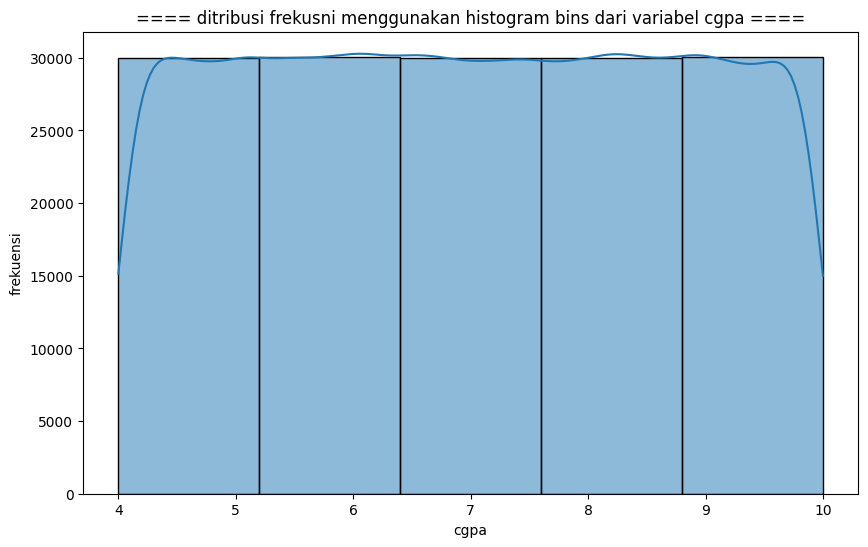

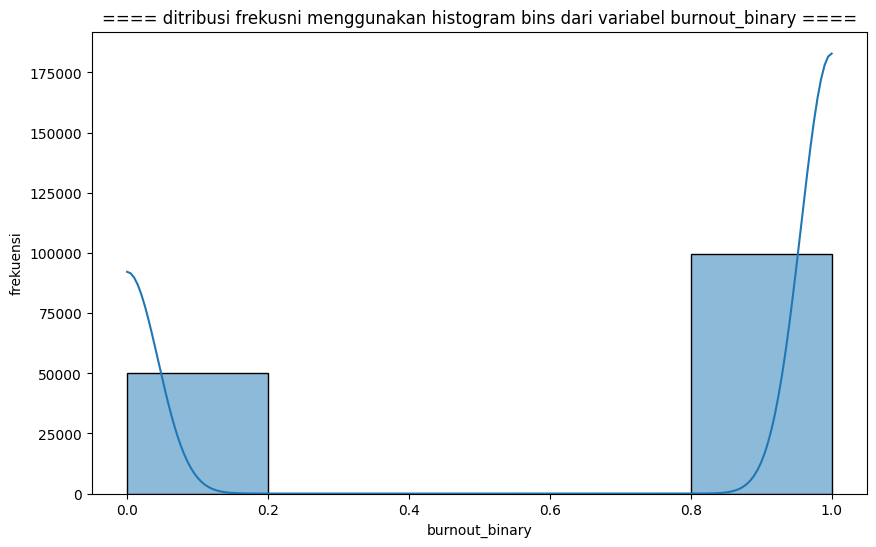

In [35]:
#distribusi frekuensi pada data numerik menggunakan histogrtam bins
for i in data_numerik.columns:
    plt.figure(figsize=(10,6))
    plt.title(f"==== ditribusi frekusni menggunakan histogram bins dari variabel {i} ====")
    sns.histplot(data= data_numerik, x=i, bins=5, kde=True)
    plt.xlabel(i)
    plt.ylabel('frekuensi')
    plt.show() #melihat distribusi frekuensi pada data numerik menggunakan histogram bins    


burnout_binary


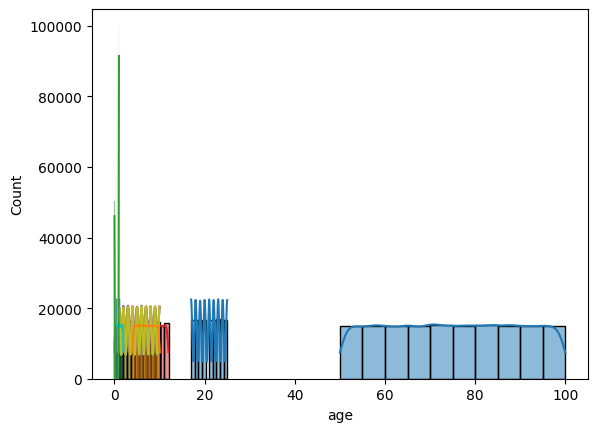

In [34]:
for i in data_numerik.columns:
    sns.histplot(data=data_numerik, x=i, bins=10, kde=True)
print(i)

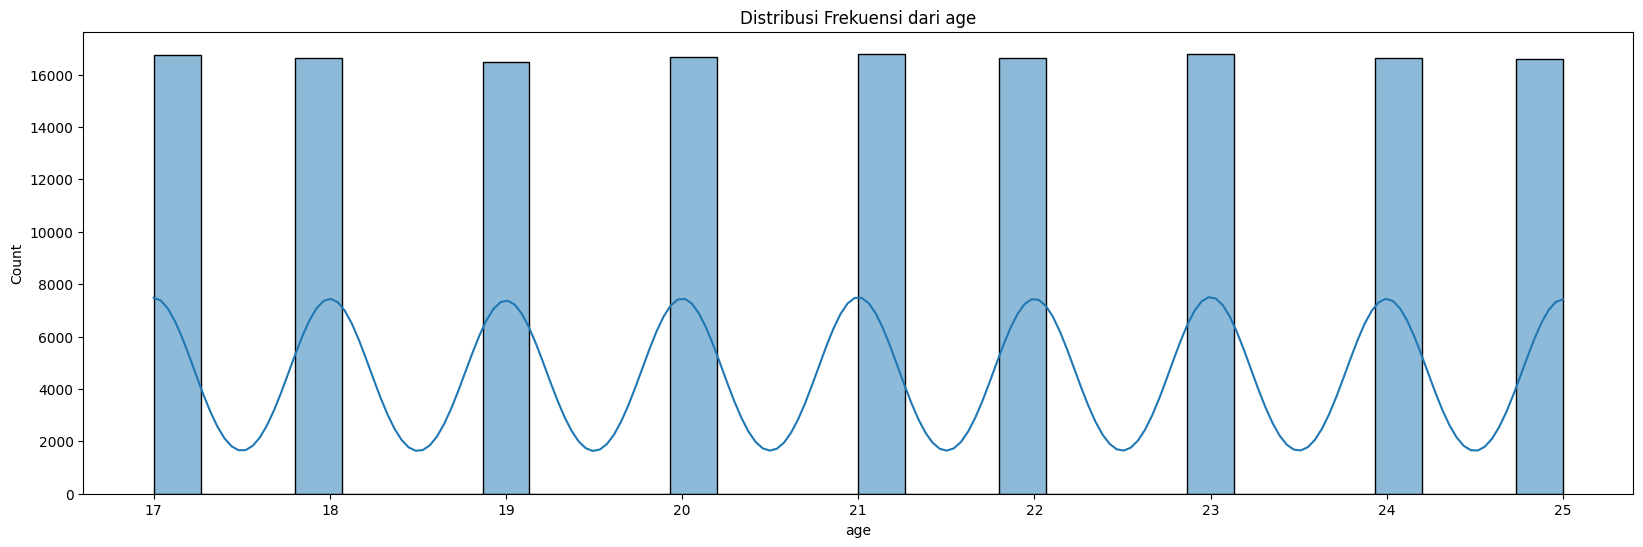

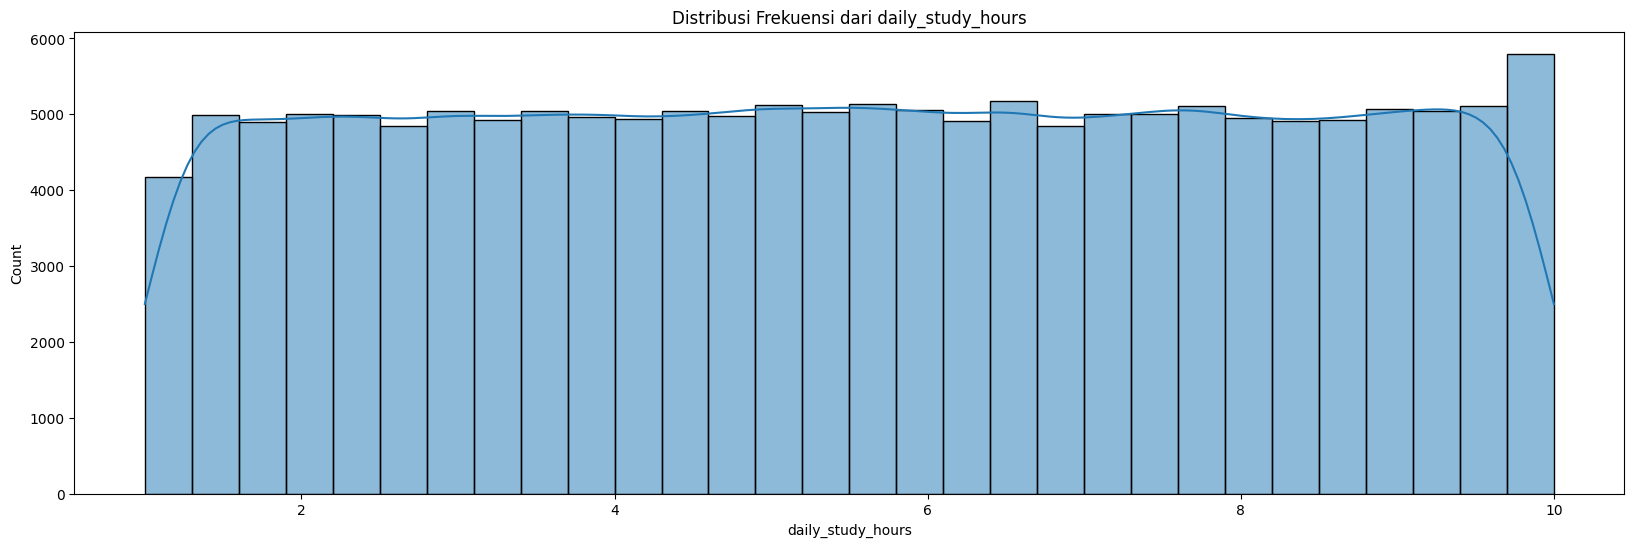

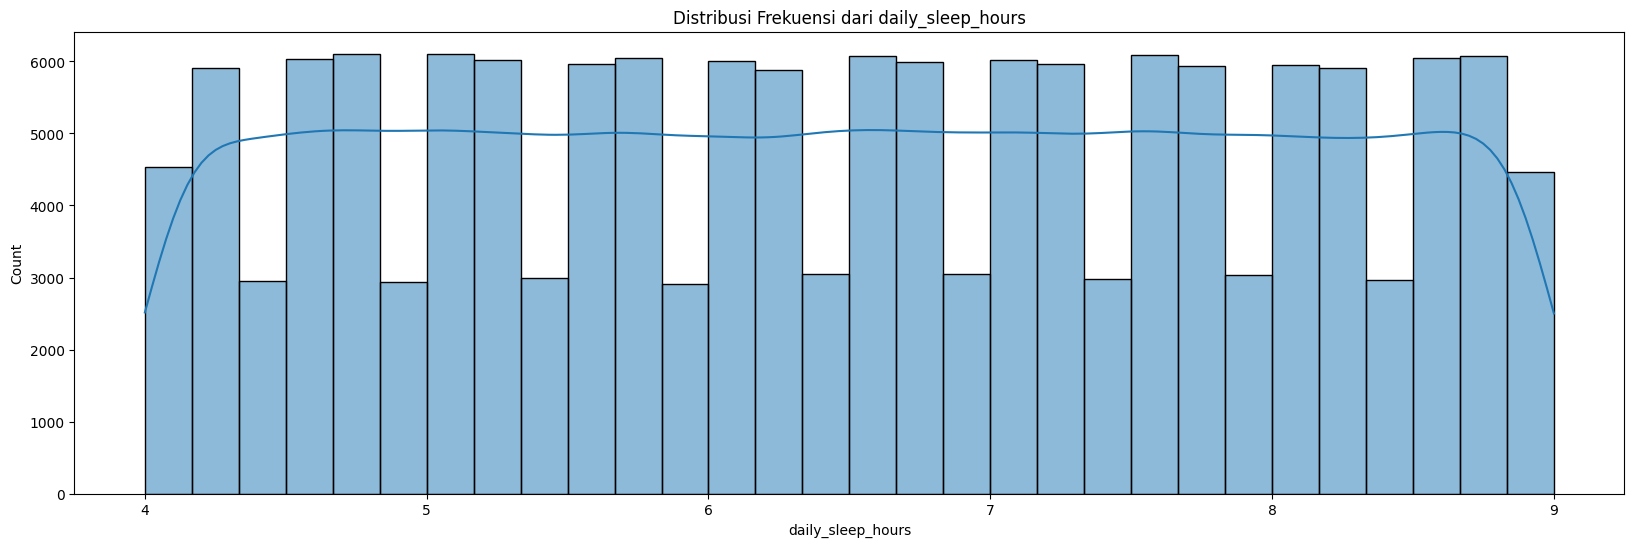

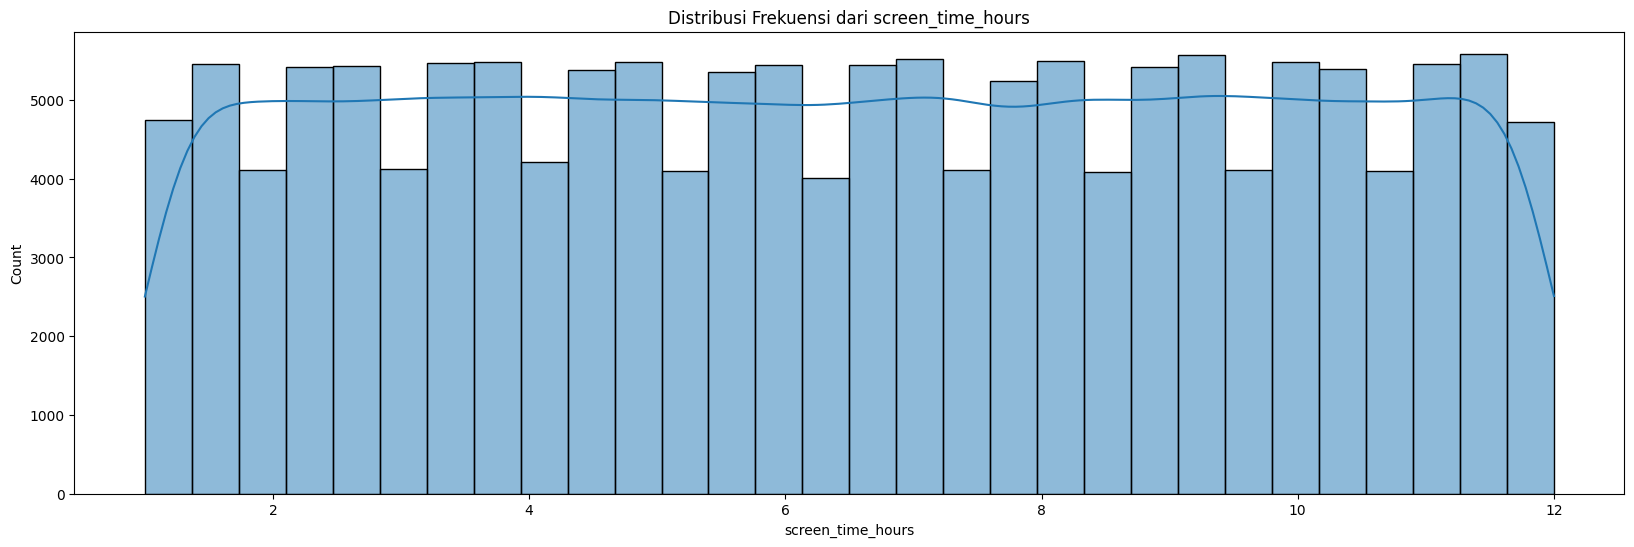

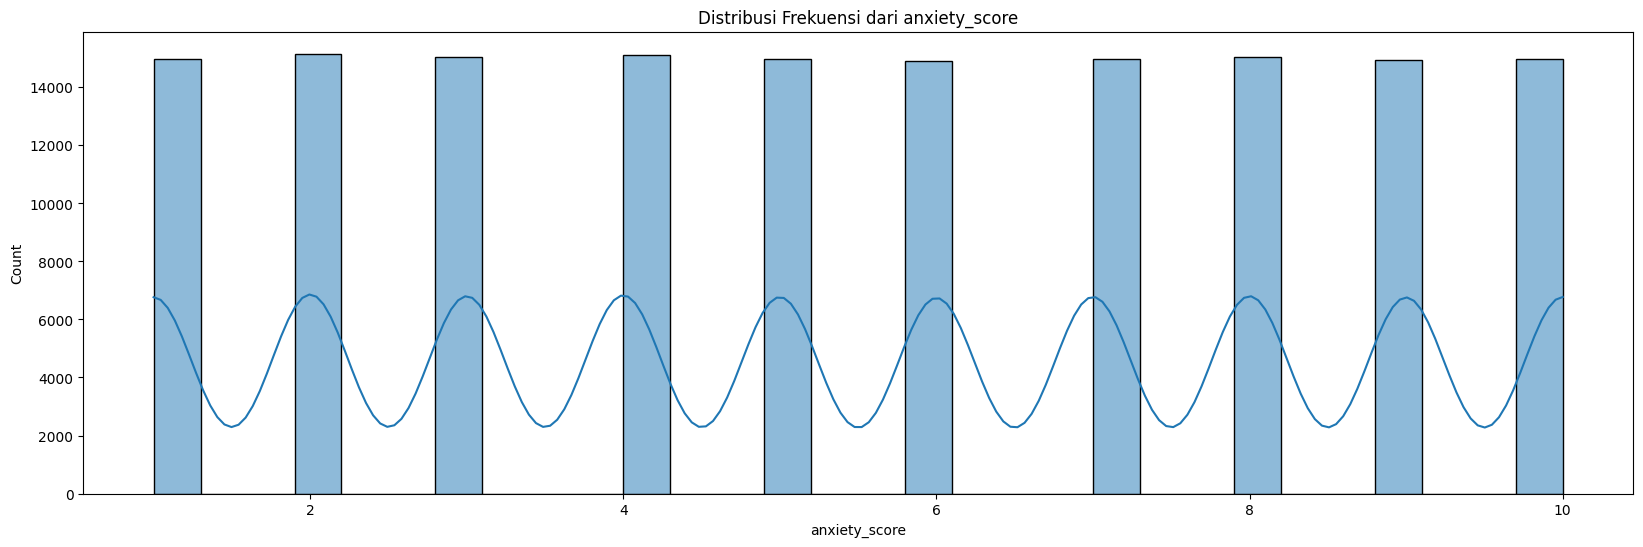

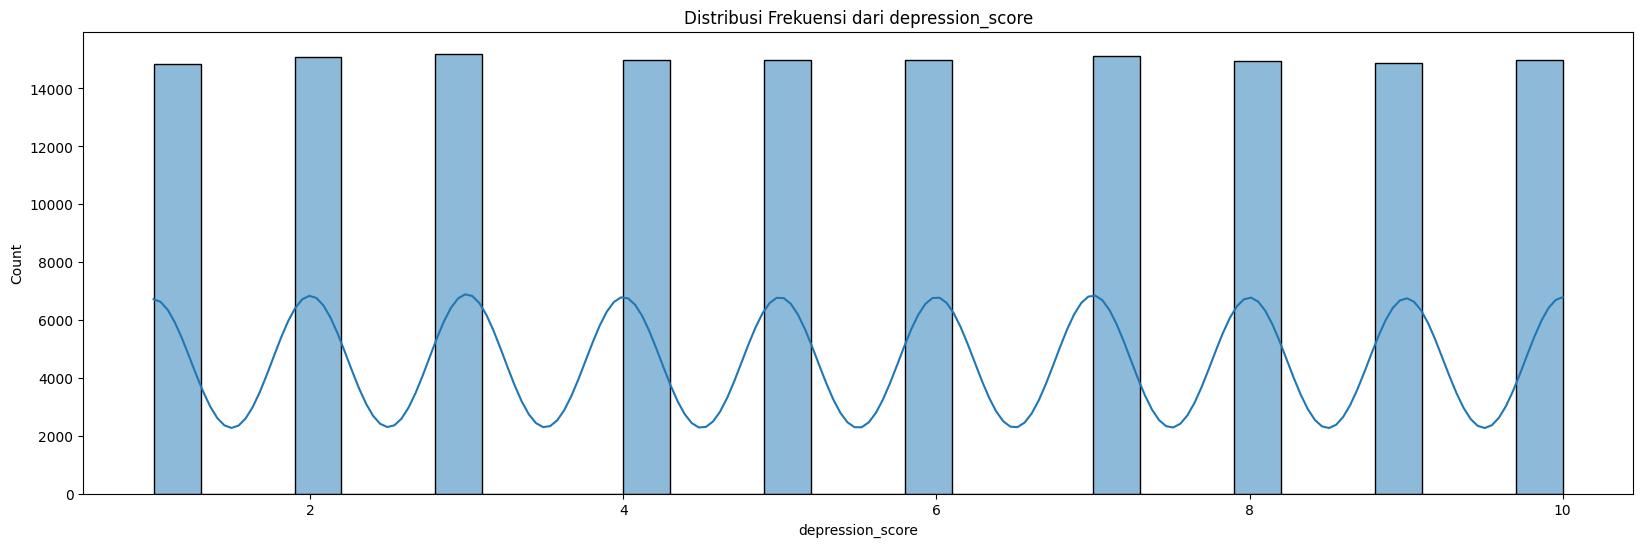

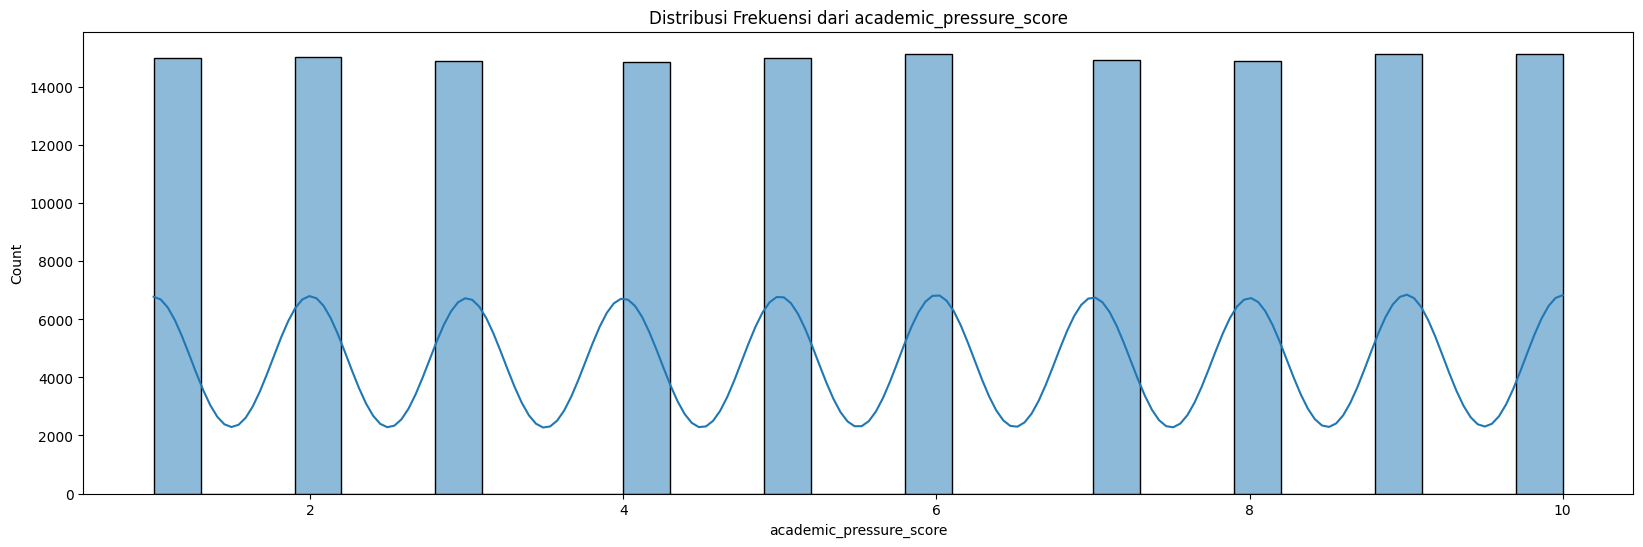

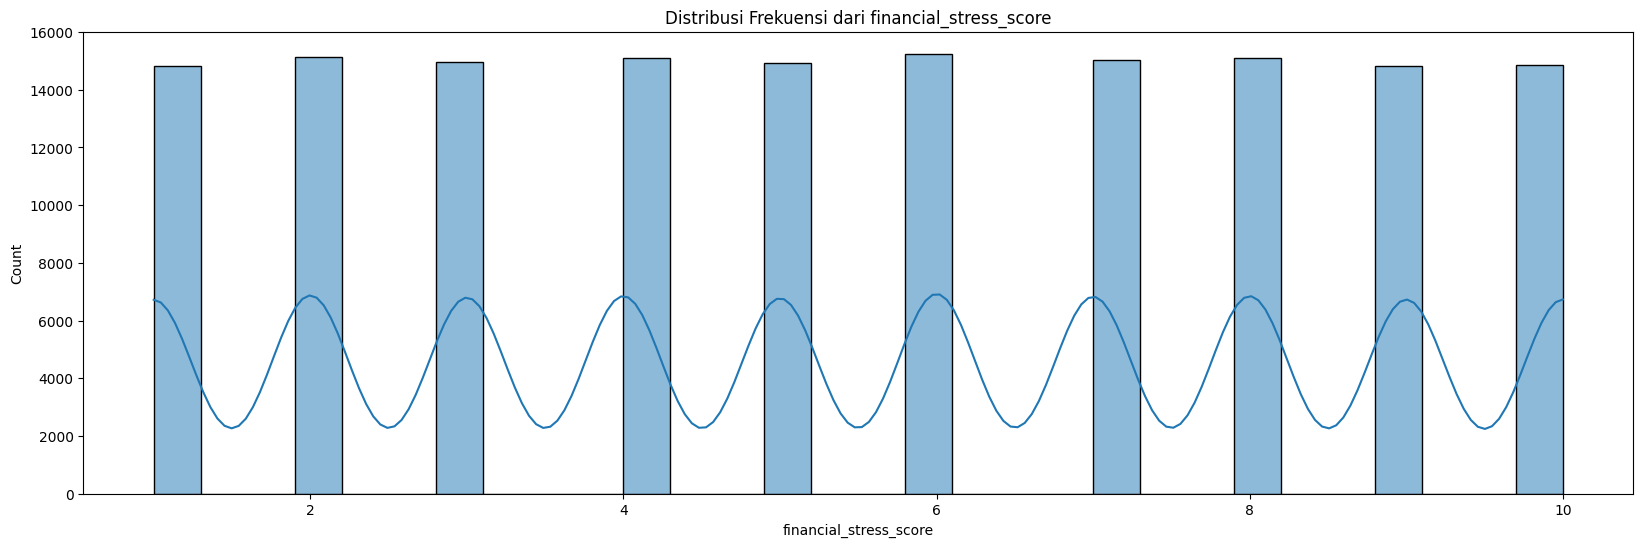

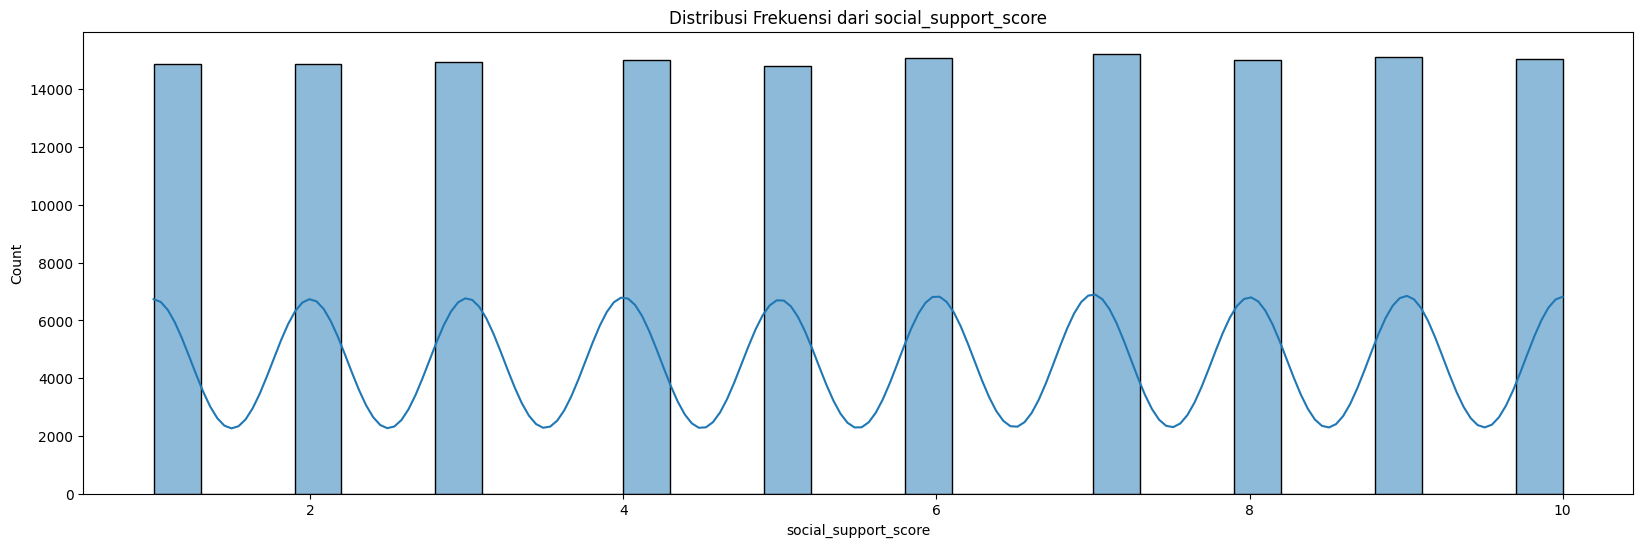

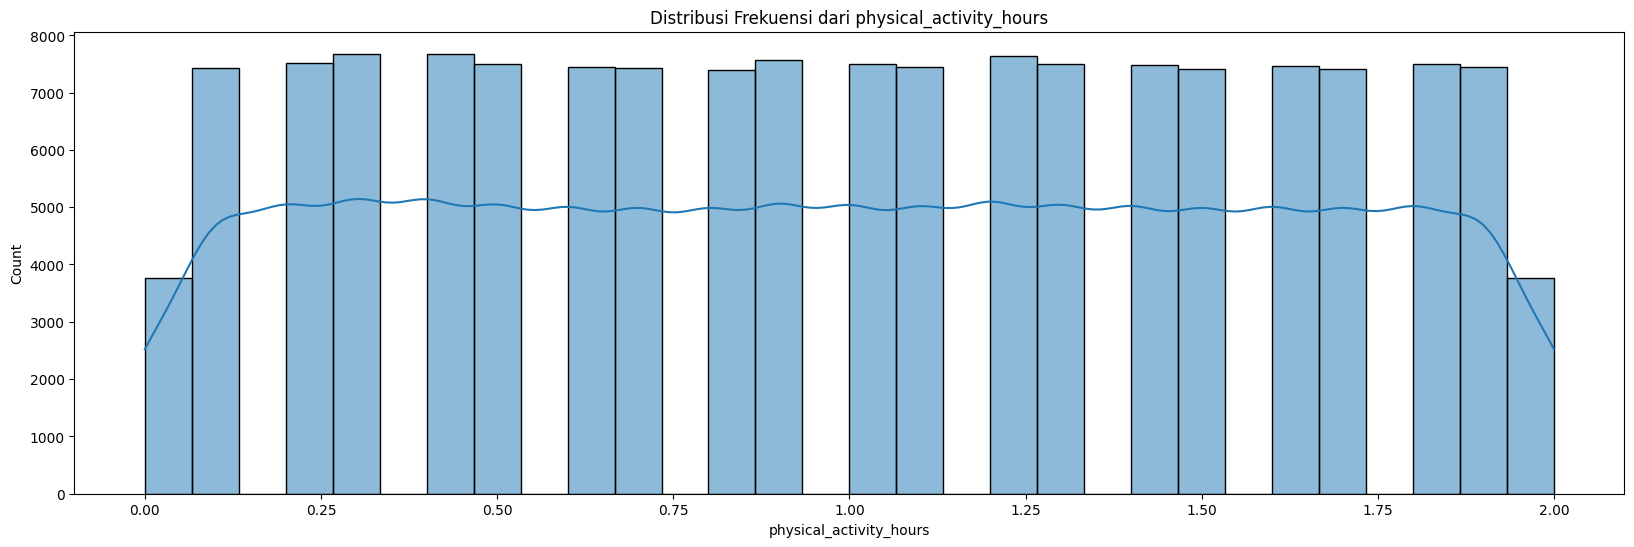

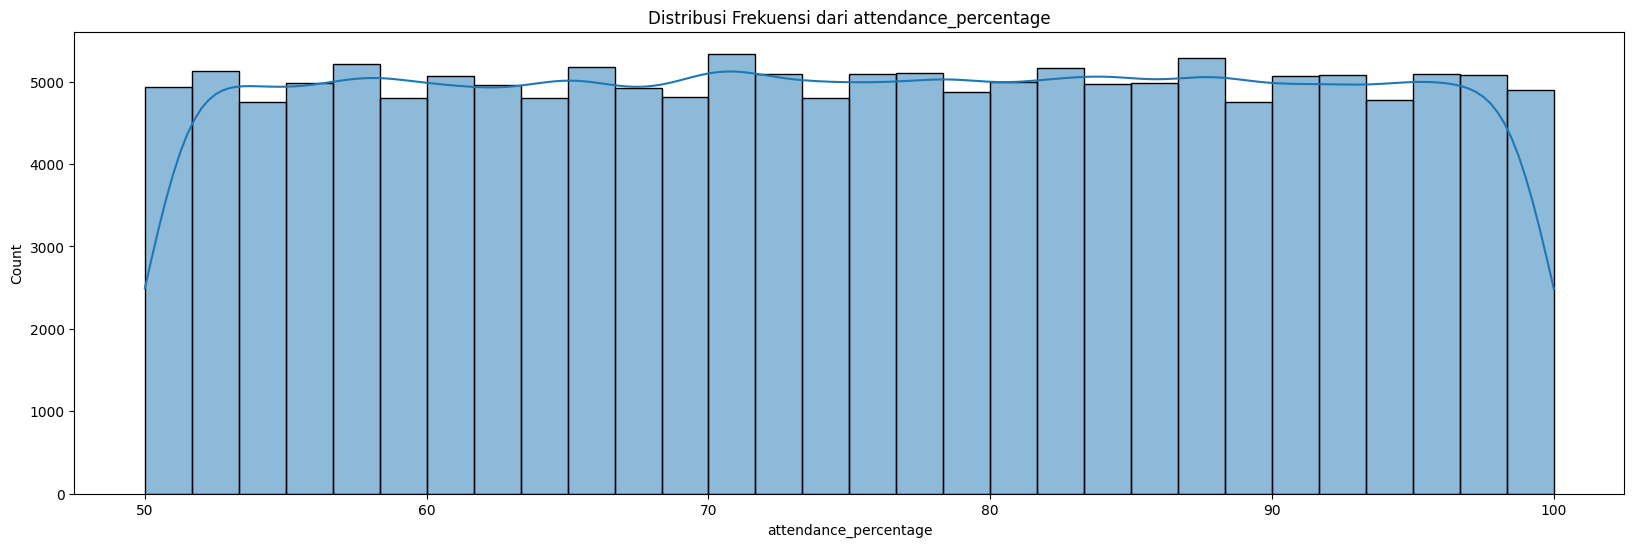

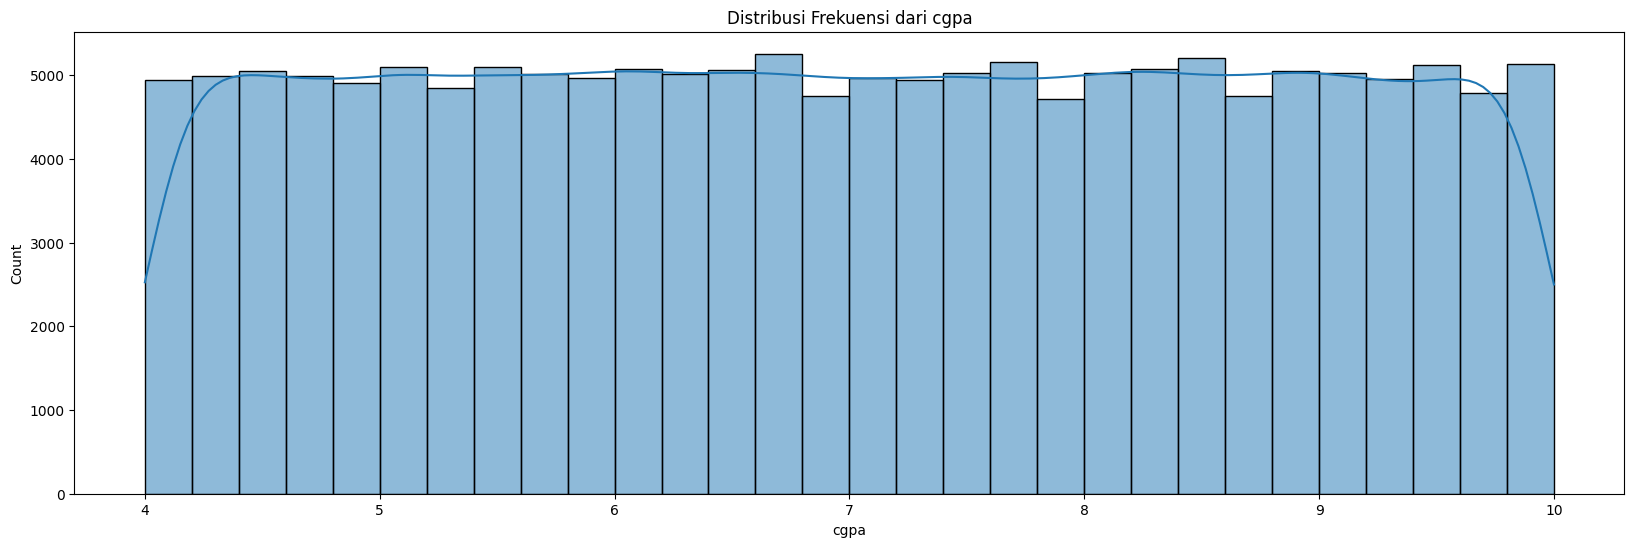

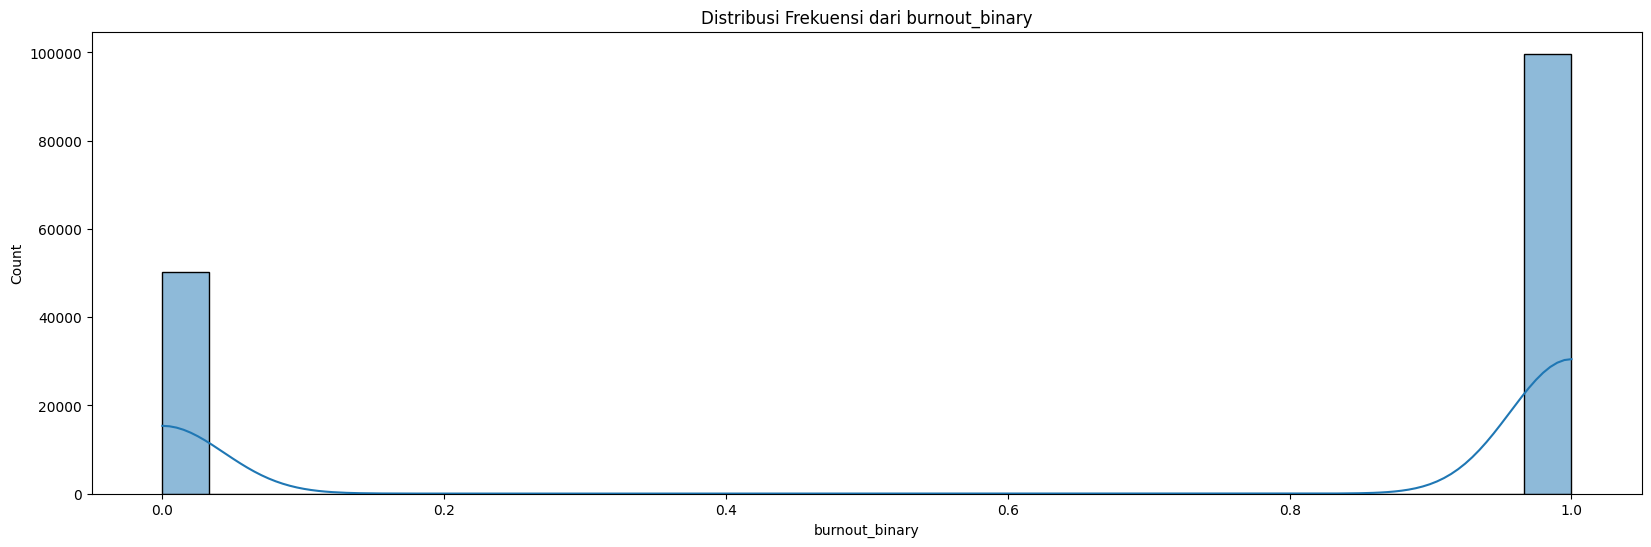

In [15]:
for i in data_numerik.columns:
    plt.figure(figsize=(20,6))
    plt.title(f'Distribusi Frekuensi dari {i}')
    sns.histplot(data=data_numerik, x=i, bins=30, kde=True)
    plt.show() #melihat distribusi frekuensi dari data set kita

In [16]:
#melihat nilai tengah di data set kita
#melihat data tengah untuk data numeri integer dan data numeri float
data_finalmodel[['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'attendance_percentage', 'cgpa',
       'burnout_binary']].median()

age                        21.00
daily_study_hours           5.50
daily_sleep_hours           6.50
screen_time_hours           6.50
anxiety_score               5.00
depression_score            5.00
academic_pressure_score     6.00
financial_stress_score      6.00
social_support_score        6.00
physical_activity_hours     1.00
attendance_percentage      75.00
cgpa                        6.99
burnout_binary              1.00
dtype: float64

In [17]:
#melihat data tengah untuk data numeri integer

data_finalmodel[['age', 'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score', 'burnout_binary']].median()

age                        21.0
anxiety_score               5.0
depression_score            5.0
academic_pressure_score     6.0
financial_stress_score      6.0
social_support_score        6.0
burnout_binary              1.0
dtype: float64

In [18]:
data_finalmodel["age"].value_counts() #melihat jumlah

age
23    16796
21    16777
17    16730
20    16671
18    16645
24    16643
22    16640
25    16603
19    16495
Name: count, dtype: int64

In [19]:

data_finalmodel.select_dtypes(exclude=['object', 'float']).columns #mme,lihat data yang bertipe integer pada data set kita

Index(['age', 'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score', 'burnout_binary'],
      dtype='object')

In [20]:
data_finalmodel.select_dtypes(include='object').columns #melihat data yang bertipe object pada data set kita

Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality'],
      dtype='object')

In [21]:
#aspliting data set

x = data_finalmodel.drop(columns=['burnout_binary']) #memisahkan data fitur dengan data target
y = data_finalmodel['burnout_binary']

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y, test_size= 0.3, random_state=42) #memisahkan data latih dan data uji dengan rasio 70:30

print(x.shape) #melihat jumlah data fitur
print(y.shape) #melihat jumlah data target

(150000, 18)
(150000,)


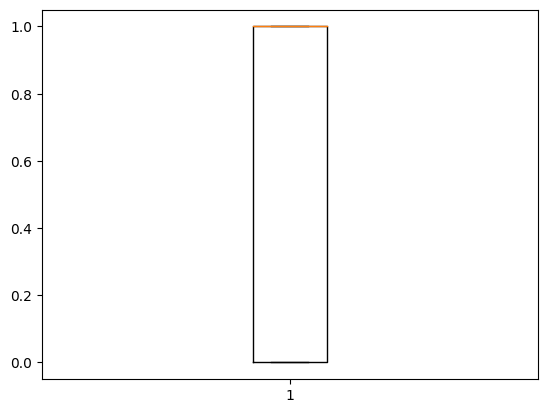

In [22]:
#outliers detectore mengunkan IQR method
Q1 = data_model['burnout_binary'].quantile(0.25)
Q3 = data_model['burnout_binary'].quantile(0.75)

IQR = Q3 - Q1

lower_data = Q1 - 1.5 * IQR
upper_data = Q3 + 1.5 * IQR

oulierts_detector = data_model[
    (data_model['burnout_binary'] < lower_data) | (data_model['burnout_binary'] > upper_data)
]

oulierts_detector
plt.boxplot(data_model['burnout_binary'])
plt.show()


In [23]:
data_object.describe()

,gender,course,year,stress_level,sleep_quality,internet_quality
count,150000,150000,150000,150000,150000,150000
unique,3,6,4,3,3,3
top,Other,MBA,1st,High,Good,Average
freq,50048,25231,37680,50295,50143,50138


In [24]:
data_object.value_counts(normalize=True).head(50) * 100 
# melihat persentase data teratas pada data set kita

gender  course  year  stress_level  sleep_quality  internet_quality
Male    BBA     2nd   Low           Poor           Average             0.070667
Other   MBA     3rd   Low           Good           Average             0.070000
        BCA     2nd   High          Good           Poor                0.067333
Male    BBA     1st   Low           Average        Average             0.067333
Other   BCA     1st   Medium        Average        Good                0.067333
Female  MBA     2nd   Medium        Poor           Good                0.067333
Other   MCA     2nd   Low           Average        Good                0.066667
Female  MCA     1st   Medium        Good           Poor                0.066667
Other   BTech   4th   Low           Good           Poor                0.066000
Male    BTech   2nd   High          Good           Average             0.066000
Other   BTech   2nd   Medium        Poor           Poor                0.066000
        BBA     2nd   Medium        Average        P

In [25]:
data_object

,gender,course,year,stress_level,sleep_quality,internet_quality
0,Male,BTech,1st,High,Average,Good
1,Male,BTech,3rd,High,Poor,Poor
2,Female,BCA,4th,Low,Good,Good
3,Male,BSc,4th,High,Poor,Good
4,Other,BSc,4th,High,Good,Good
...,...,...,...,...,...,...
149995,Female,BSc,3rd,Medium,Good,Good
149996,Male,BCA,3rd,High,Poor,Average
149997,Male,BTech,1st,High,Good,Average
149998,Male,BSc,3rd,Medium,Average,Average


In [26]:
for i in data_object.columns:
    nilai_porpriso = data_object[i].value_counts(normalize=True) * 100 #melihat proporsi data
    print(f'PROPORSI DATA - {i}')
    print(nilai_porpriso)

PROPORSI DATA - gender
gender
Other     33.365333
Female    33.325333
Male      33.309333
Name: proportion, dtype: float64
PROPORSI DATA - course
course
MBA      16.820667
BBA      16.735333
BCA      16.648667
MCA      16.633333
BSc      16.596000
BTech    16.566000
Name: proportion, dtype: float64
PROPORSI DATA - year
year
1st    25.120000
4th    25.081333
3rd    24.948000
2nd    24.850667
Name: proportion, dtype: float64
PROPORSI DATA - stress_level
stress_level
High      33.530000
Medium    33.393333
Low       33.076667
Name: proportion, dtype: float64
PROPORSI DATA - sleep_quality
sleep_quality
Good       33.428667
Average    33.317333
Poor       33.254000
Name: proportion, dtype: float64
PROPORSI DATA - internet_quality
internet_quality
Average    33.425333
Poor       33.326000
Good       33.248667
Name: proportion, dtype: float64


In [27]:
#melihat data IR ( imabalence rasio) mengunakn if statement


for i in data_object.columns:
    
    jumlan = data_object[i].value_counts() #bagian ini untuk menghitung dsitribusi data disetiap class

    
    max_value = jumlan.max()
    min_value = jumlan.min()
    
    rasio = max_value / min_value
    
    if rasio < 1.5:
        print(f"data tidak imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    elif rasio > 1.5 and rasio <= 3:
        print(f"data sedikit imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    else:
        print(f"data imbalence pada kolom {i} dengan rasio{rasio:.2f}")

data tidak imbalence pada kolom gender dengan rasio1.00
data tidak imbalence pada kolom course dengan rasio1.02
data tidak imbalence pada kolom year dengan rasio1.01
data tidak imbalence pada kolom stress_level dengan rasio1.01
data tidak imbalence pada kolom sleep_quality dengan rasio1.01
data tidak imbalence pada kolom internet_quality dengan rasio1.01


In [28]:

imbalance_rasio = y_latih.value_counts()
rasio = imbalance_rasio.max() / imbalance_rasio.min()

if rasio < 1.5:
    print(f'data aman tidak imbalence {rasio}')
elif rasio > 1.5 and rasio <= 3:
    print(f"sedikit imbalence {rasio}")
else:
    print(f"data imbalence {rasio}")


sedikit imbalence 1.9888983774551665


In [29]:
data_numerik = x_latih.select_dtypes(include=['float64', 'int64']) #melihat data yang bertipe numerik pada data set kita

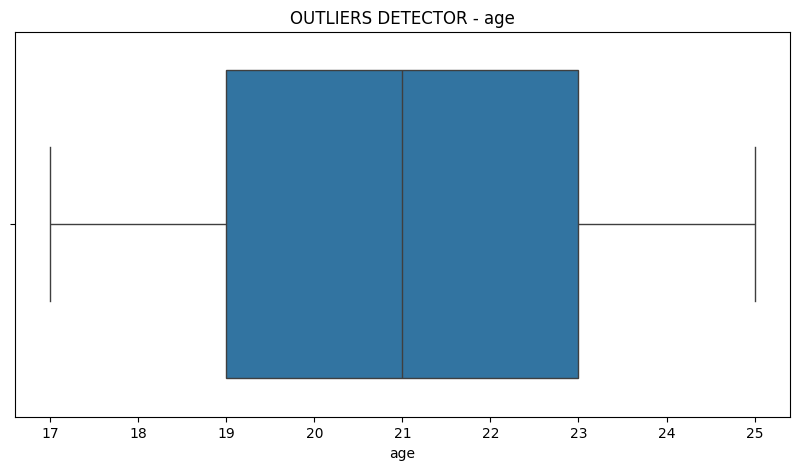

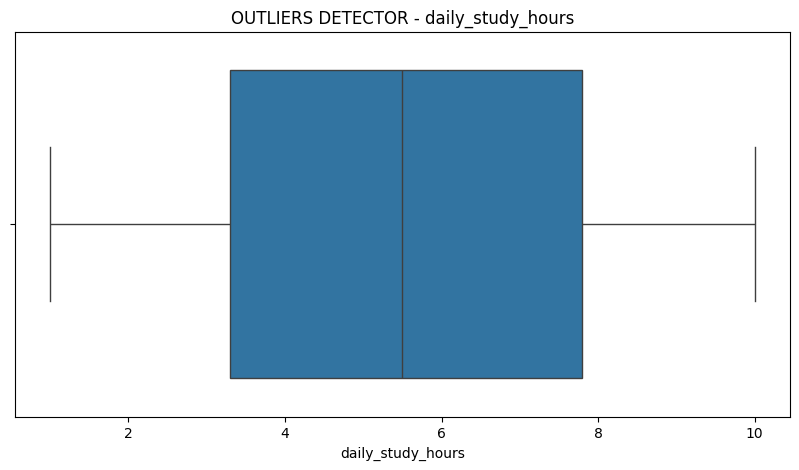

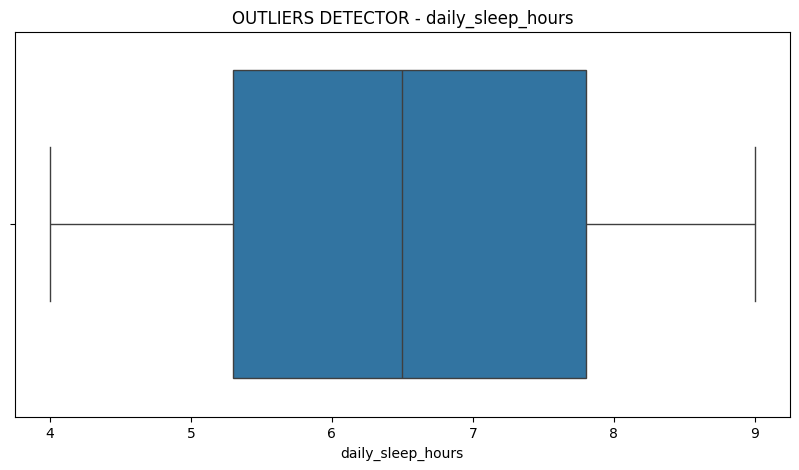

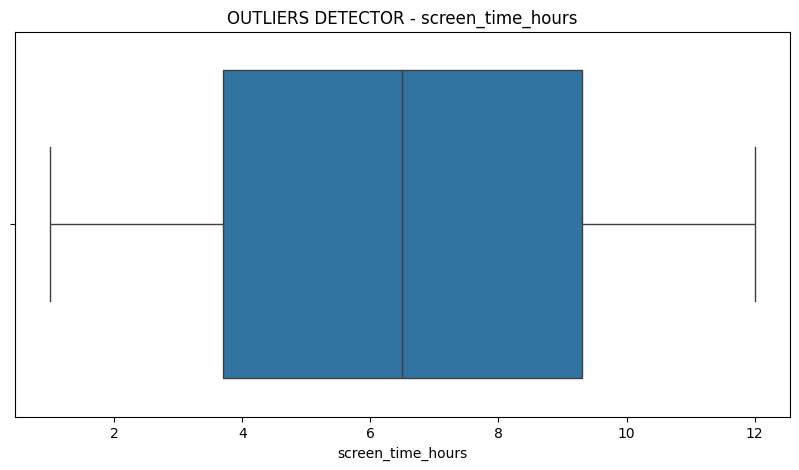

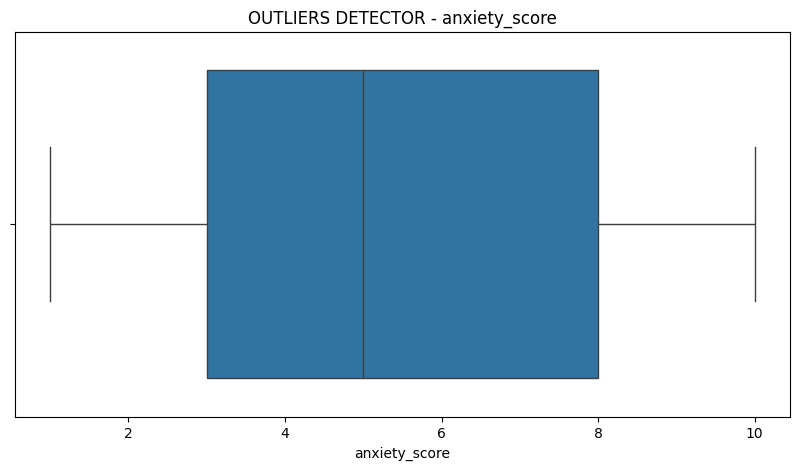

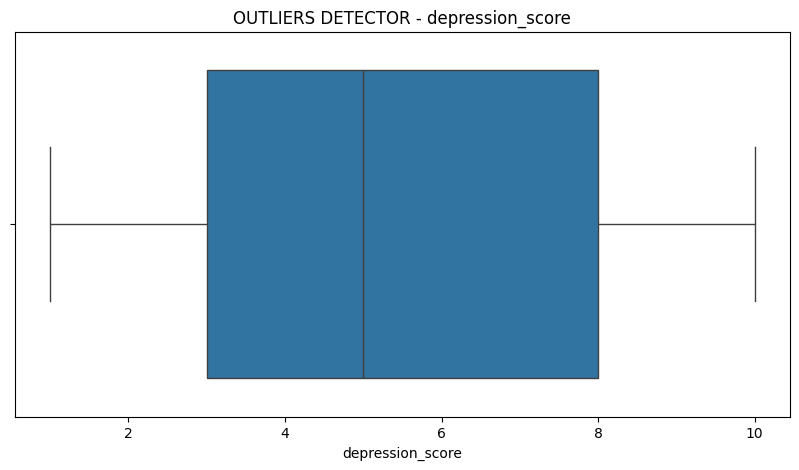

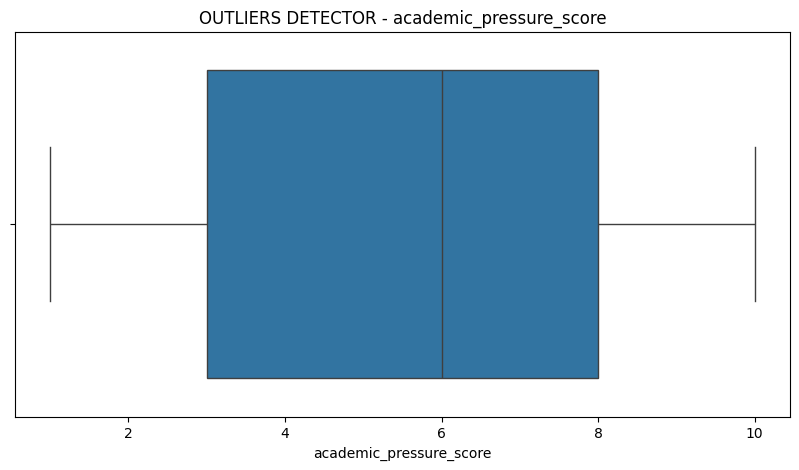

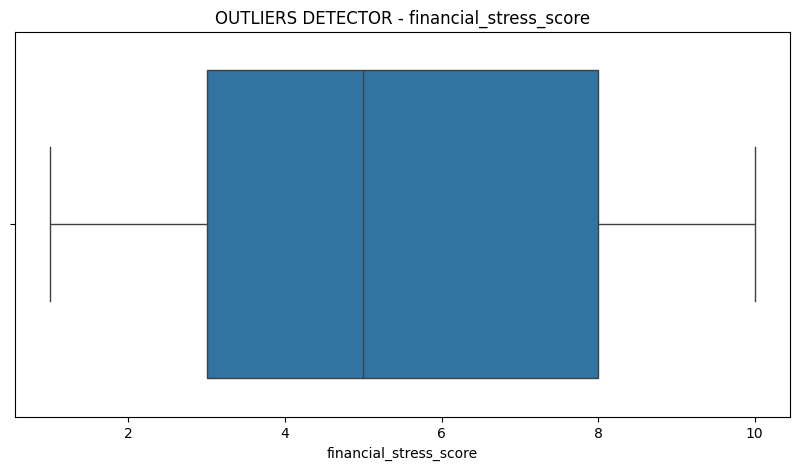

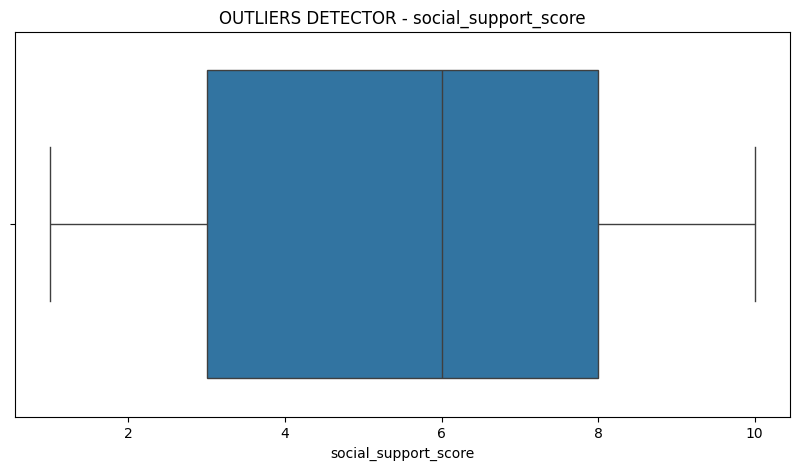

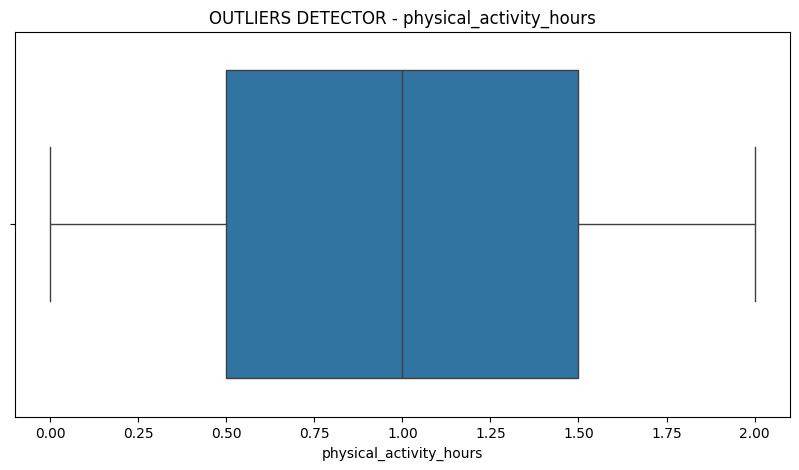

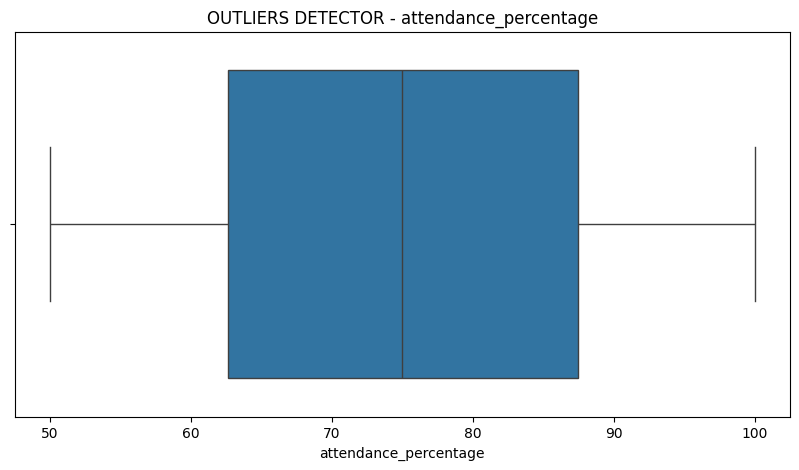

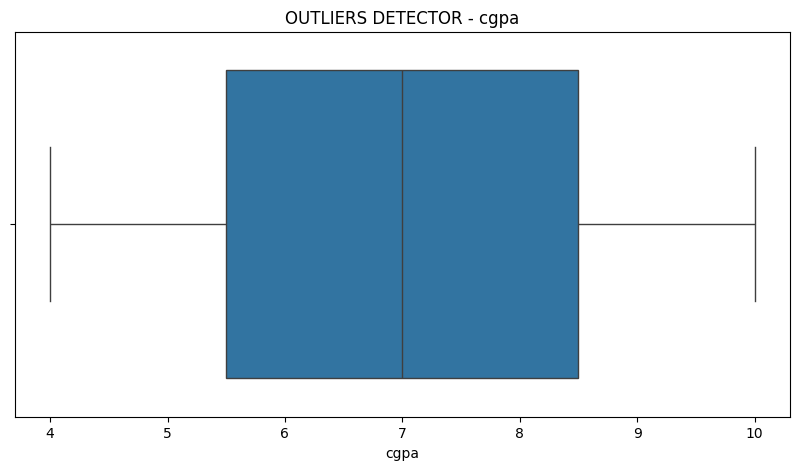

In [30]:


#outlier detection mengunkan boxplot
#kirta gunakan x_latih karna kita sudah spliting dahulu data nya
for column in x_latih.select_dtypes(include=['float64', 'int64']).columns: #disini kita menggabil data numerik saja karna outliers biasa nya hanya untuk data numerik
    plt.figure(figsize=(10, 5))
    sns.boxplot(x =x_latih[column])
    plt.title(f'OUTLIERS DETECTOR - {column}')
    plt.show()

In [31]:
data_numerik

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
27822,21,8.3,7.8,9.8,6,9,8,6,10,1.9,58.2,6.13
85202,18,9.8,7.4,2.0,4,4,5,8,3,1.6,72.9,4.87
42217,24,1.5,6.0,9.3,7,3,6,8,7,0.6,74.2,8.30
119958,21,1.3,8.0,11.0,4,7,5,10,6,0.4,58.3,5.32
37678,20,4.0,7.9,1.8,5,8,1,2,8,0.8,67.2,6.22
...,...,...,...,...,...,...,...,...,...,...,...,...
119879,24,4.3,4.7,2.3,10,6,1,5,10,1.3,77.6,5.77
103694,21,6.4,5.2,1.9,8,4,1,7,8,1.0,54.0,8.74
131932,18,2.6,6.6,3.5,4,6,2,5,10,0.4,88.9,8.01
146867,17,6.6,5.9,11.6,6,1,5,5,9,0.2,72.8,6.23
